Регресійний аналіз не з'ясовує чи істотний зв'язок,
а займається пошуком моделі цього зв'язку, вираженої у функції регресії.

Мета лінійної регресії:
    знаходження лінійного зв'язку між вхідними ознаками (пояснюючими змінними) і вихідними значеннями (відгуком).

y = w0 + w1*x (w0 - bias (intercept))
y^ = w0 + w1*x + e (w - params, y^ - predicted val, y - table val of target val, x - feature val, e - error)
Під час навчання алгоритм підбирає ваги w0 and w1, щоб мінімізувати цю похибку (grad descent / optimization f(x))

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

In [3]:
x = [[1.2], [2.5], [3.1], [4.3], [5.7]]
y = [[5.4], [8], [9.2], [11.6], [14.4]]

In [4]:
regressor = LinearRegression().fit(x,y)

In [5]:
print(regressor.coef_)

[[2.]]


In [6]:
print(regressor.intercept_)

[3.]


In [10]:
# Перевірка linear regression = w*x + b
print(x[0]*regressor.coef_+regressor.intercept_)

[[5.4]]


### Regression on "MPG" (Miles Per Gallon)

- **mpg** (miles per gallon): пробіг на галон пального (числова величина).
- **cylinders**: кількість циліндрів у двигуні (категоріальна змінна).
- **displacement**: об'єм двигуна в кубічних дюймах (числова величина).
- **horsepower**: потужність двигуна (числова величина).
- **weight**: вага автомобіля (числова величина).
- **acceleration**: прискорення (числова величина).
- **model year**: рік випуску моделі (категоріальна змінна).
- **origin**: країна походження (категоріальна змінна).
- **car name**: індеск автомобіля.


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels as sm

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, explained_variance_score, mean_pinball_loss
from sklearn import preprocessing
from sklearn.neighbors import KNeighborsRegressor
from sklearn import svm
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
import scipy
from sklearn.inspection import DecisionBoundaryDisplay

In [ ]:
# Отримання даних MPG (install ucimlrepo)
# !pip install ucimlrepo

In [15]:
from ucimlrepo import fetch_ucirepo
auto_mpg = fetch_ucirepo(id=9)

In [20]:
# data (in pd df)
X = auto_mpg.data.features
y = auto_mpg.data.targets
X

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin
0,307.0,8,130.0,3504,12.0,70,1
1,350.0,8,165.0,3693,11.5,70,1
2,318.0,8,150.0,3436,11.0,70,1
3,304.0,8,150.0,3433,12.0,70,1
4,302.0,8,140.0,3449,10.5,70,1
...,...,...,...,...,...,...,...
393,140.0,4,86.0,2790,15.6,82,1
394,97.0,4,52.0,2130,24.6,82,2
395,135.0,4,84.0,2295,11.6,82,1
396,120.0,4,79.0,2625,18.6,82,1


In [23]:
y

,mpg
0,18.0
1,15.0
2,18.0
3,16.0
4,17.0
...,...
393,27.0
394,44.0
395,32.0
396,28.0


In [21]:
print(auto_mpg.metadata)

{'uci_id': 9, 'name': 'Auto MPG', 'repository_url': 'https://archive.ics.uci.edu/dataset/9/auto+mpg', 'data_url': 'https://archive.ics.uci.edu/static/public/9/data.csv', 'abstract': 'Revised from CMU StatLib library, data concerns city-cycle fuel consumption', 'area': 'Other', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 398, 'num_features': 7, 'feature_types': ['Real', 'Categorical', 'Integer'], 'demographics': [], 'target_col': ['mpg'], 'index_col': ['car_name'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1993, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5859H', 'creators': ['R. Quinlan'], 'intro_paper': None, 'additional_info': {'summary': 'This dataset is a slightly modified version of the dataset provided in the StatLib library.  In line with the use by Ross Quinlan (1993) in predicting the attribute "mpg", 8 of the original instances were removed because they had unknown values for th

In [22]:
print(auto_mpg.variables)

           name     role         type demographic description units  \
0  displacement  Feature   Continuous        None        None  None   
1           mpg   Target   Continuous        None        None  None   
2     cylinders  Feature      Integer        None        None  None   
3    horsepower  Feature   Continuous        None        None  None   
4        weight  Feature   Continuous        None        None  None   
5  acceleration  Feature   Continuous        None        None  None   
6    model_year  Feature      Integer        None        None  None   
7        origin  Feature      Integer        None        None  None   
8      car_name       ID  Categorical        None        None  None   

  missing_values  
0             no  
1             no  
2             no  
3            yes  
4             no  
5             no  
6             no  
7             no  
8             no  


In [27]:
data = pd.concat([X,y],axis=1)
data.head()

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
0,307.0,8,130.0,3504,12.0,70,1,18.0
1,350.0,8,165.0,3693,11.5,70,1,15.0
2,318.0,8,150.0,3436,11.0,70,1,18.0
3,304.0,8,150.0,3433,12.0,70,1,16.0
4,302.0,8,140.0,3449,10.5,70,1,17.0


In [29]:
data.index

RangeIndex(start=0, stop=398, step=1)

In [30]:
data.columns

Index(['displacement', 'cylinders', 'horsepower', 'weight', 'acceleration',
       'model_year', 'origin', 'mpg'],
      dtype='object')

In [33]:
data.shape #розмір ьаблиці

(398, 8)

In [34]:
data.dtypes # types of columns

displacement    float64
cylinders         int64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin            int64
mpg             float64
dtype: object

In [35]:
data['horsepower'].unique()

array([130., 165., 150., 140., 198., 220., 215., 225., 190., 170., 160.,
        95.,  97.,  85.,  88.,  46.,  87.,  90., 113., 200., 210., 193.,
        nan, 100., 105., 175., 153., 180., 110.,  72.,  86.,  70.,  76.,
        65.,  69.,  60.,  80.,  54., 208., 155., 112.,  92., 145., 137.,
       158., 167.,  94., 107., 230.,  49.,  75.,  91., 122.,  67.,  83.,
        78.,  52.,  61.,  93., 148., 129.,  96.,  71.,  98., 115.,  53.,
        81.,  79., 120., 152., 102., 108.,  68.,  58., 149.,  89.,  63.,
        48.,  66., 139., 103., 125., 133., 138., 135., 142.,  77.,  62.,
       132.,  84.,  64.,  74., 116.,  82.])

In [36]:
data.cylinders.unique()

array([8, 4, 6, 3, 5])

In [ ]:
# Видалення спостережень (строк) з nan значеннями
data = data.dropna()
np.shape(data)

# OR pandas median (середнє значення)
# data = data.fillna(data.median(numeric_only=True))

(392, 8)

#### Основні статистики, що описують дані

- mean - вибіркове (емпіричне) середнє значення
- std - стандартне відхилення
- 25%, 50%, 75% - квантиль

In [40]:
data['mpg'].describe()

count    392.000000
mean      23.445918
std        7.805007
min        9.000000
25%       17.000000
50%       22.750000
75%       29.000000
max       46.600000
Name: mpg, dtype: float64

/var/folders/52/8y5ry6cn6lb3856sdgttfvl80000gn/T/ipykernel_13439/4215132924.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['mpg'])


<Axes: xlabel='mpg', ylabel='Density'>

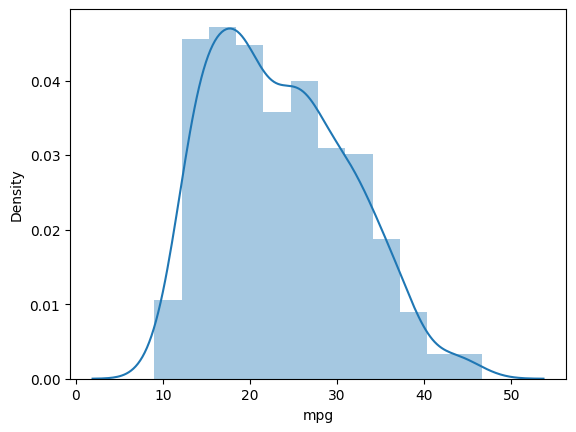

In [48]:
# Візуалізація розподілу цільової змінної
sns.distplot(data['mpg'])

#### Коефіцієнт асиметрії **skewness**
числова характеристика розподілу ймовірностей дійсної випадкової величини (negative -> right, positive->left)

#### Коефіцієнт ексцесу **Kurtosis**
характеризує «крутість», тобто, стрімкість підвищення кривої розподілу у порівнянні з нормальною кривою.

In [52]:
print("Skewness: %f" % data['mpg'].skew())

Skewness: 0.457092


In [58]:
print("Kurtosis: %f" % data['mpg'].kurt())

Kurtosis: -0.515993
